Data ingestion & cleaning

In [ ]:
import pandas as pd


In [ ]:
!pip install tabula-py
import tabula

ACS DP05 (population)

ACS S1901 (median household income)

In [ ]:
import pandas as pd

# Load cleaned ACS table files
pop = pd.read_csv("median_household_census.csv")   # DP05 (population)
inc = pd.read_csv("total_population_census.csv")    # S1901 (income)

In [ ]:
# Subset cities
cities = [
    "Phoenix city, Arizona",
    "Orlando city, Florida",
    "Atlanta city, Georgia",
    "Dallas city, Texas",
]

pop = pop[pop["NAME"].isin(cities)]
inc = inc[inc["NAME"].isin(cities)]

In [ ]:
#Extract needed fields
pop_clean = pop[["NAME", "DP05_0001E"]].rename(
    columns={"DP05_0001E": "total_population"}
)

inc_clean = inc[["NAME", "S1901_C01_012E"]].rename(
    columns={"S1901_C01_012E": "median_household_income"}
)

#Merge
acs = pop_clean.merge(inc_clean, on="NAME", how="inner")

#Add simplified city column
acs["city"] = acs["NAME"].str.split(",").str[0]

acs

,NAME,total_population,median_household_income,city
0,"Phoenix city, Arizona",1673122,85246,Phoenix city
1,"Orlando city, Florida",334871,77597,Orlando city
2,"Atlanta city, Georgia",520066,88165,Atlanta city
3,"Dallas city, Texas",1326093,74323,Dallas city


DOT traffic datasets

In [ ]:
import pandas as pd

atl = pd.read_csv("aadt_atlanta.csv")
atl.columns

Index(['Station ID', 'Functional Class', 'Latitude', 'Longitude', 'AADT_2024',
       'Truck%_2024', 'AADT_2023', 'Truck%_2023', 'AADT_2022', 'Truck%_2022',
       'AADT_2021', 'Truck%_2021', 'AADT_2020', 'Truck%_2020', 'AADT_2019',
       'Truck%_2019', 'AADT_2018', 'Truck%_2018', 'AADT_2017', 'Truck%_2017',
       'AADT_2016', 'Truck%_2016', 'AADT_2015', 'Truck%_2015', 'AADT_2014',
       'Truck%_2014'],
      dtype='object')

In [ ]:
#only keep columns we need
atl_clean = (
    atl[["Latitude", "Longitude", "AADT_2024"]]
    .rename(columns={"AADT_2024": "aadt"})
    .dropna(subset=["aadt"])
)

#Compute Atlanta's traffic index (mean AADT)
atl_city = (
    atl_clean
    .assign(city="Atlanta")
    .groupby("city", as_index=False)["aadt"].mean()
    .rename(columns={"aadt": "traffic_index"})
)

atl_city

,city,traffic_index
0,Atlanta,7853.866858


In [ ]:
# Load Dallas AADT file
dal = pd.read_csv("aadt_dallas.csv")

# Check columns first
print(dal.columns)

Index(['DIST_NBR', 'DIST_NM', 'CNTY_NBR', 'CNTY_NM', 'TRFC_STATN_ID',
       'CATEGORY', 'ACTIVE', 'AADT_RPT_YEAR', 'AADT_RPT_QTY',
       'AADT_RPT_HIST_01_QTY', 'AADT_RPT_HIST_02_QTY', 'AADT_RPT_HIST_03_QTY',
       'AADT_RPT_HIST_04_QTY', 'AADT_RPT_HIST_05_QTY', 'AADT_RPT_HIST_06_QTY',
       'AADT_RPT_HIST_07_QTY', 'AADT_RPT_HIST_08_QTY', 'AADT_RPT_HIST_09_QTY',
       'AADT_RPT_HIST_10_QTY', 'AADT_RPT_HIST_11_QTY', 'AADT_RPT_HIST_12_QTY',
       'AADT_RPT_HIST_13_QTY', 'AADT_RPT_HIST_14_QTY', 'AADT_RPT_HIST_15_QTY',
       'AADT_RPT_HIST_16_QTY', 'AADT_RPT_HIST_17_QTY', 'AADT_RPT_HIST_18_QTY',
       'AADT_RPT_HIST_19_QTY', 'ON_ROAD', 'COUNT_CYCLE', 'LATITUDE',
       'LONGITUDE', 'OBJECTID', 'x', 'y'],
      dtype='object')


In [ ]:
dal_dallas = dal[dal["CNTY_NM"] == "Dallas"].copy()


In [ ]:
dal_dallas = dal_dallas.rename(columns={"AADT_RPT_QTY": "aadt"})

dal_dallas = dal_dallas[["LATITUDE", "LONGITUDE", "aadt"]]

In [ ]:
dal_dallas = dal_dallas.dropna(subset=["aadt"])


In [ ]:
dal_city = (
    dal_dallas.assign(city="Dallas")
    .groupby("city", as_index=False)["aadt"].mean()
    .rename(columns={"aadt": "traffic_index"})
)

dal_city

,city,traffic_index
0,Dallas,36038.642127


In [ ]:
az = pd.read_excel("aadt_arizona.xlsx", header=4)
az.head()
az.columns

Index(['Section JoinID', 'Reference', 'Loc ID', 'Traffic Section Type',
       'RouteId', 'Miles', 'Road', 'From Measure', 'BMP', 'FromRoad', 'TCS MP',
       'To Measure', 'EMP', 'ToRoad', 'Pos Dir AADT', 'Neg Dir AADT',
       'AADT 2024', 'AADT Source Dataset', 'K Factor %', 'D Factor %',
       'AADT Single Trucks', 'AADT Combo Trucks', 'T Factor %',
       '2044 Future AADT', 'Type', 'Index'],
      dtype='object')

In [ ]:
phx_routes = ["I-10", "I 010", "I-17", "I 017", "L-101", "L-202", "L-303", "US 60", "US-60"]

phx = az[az["Road"].astype(str).str.contains("|".join(phx_routes), case=False, na=False)].copy()


In [ ]:
# Make sure AADT 2024 is numeric
phx["AADT 2024"] = pd.to_numeric(phx["AADT 2024"], errors="coerce")
phx = phx.dropna(subset=["AADT 2024"])

phx_city = (
    phx.assign(city="Phoenix")
       .groupby("city", as_index=False)["AADT 2024"].mean()
       .rename(columns={"AADT 2024": "traffic_index"})
)

phx_city


,city,traffic_index
0,Phoenix,27571.315526


In [ ]:
# 1. Read raw file
df_raw = pd.read_excel("aadt_orlando.xls", header=None)

# 2. Drop fully empty rows and reset index
df_raw = df_raw.dropna(how="all").reset_index(drop=True)

# 3. Use first row as header
header = df_raw.iloc[0].astype(str)
df = df_raw[1:].copy()
df.columns = header

# 4. CLEAN the column names: remove the "\n====" parts and spaces
df.columns = (
    df.columns.astype(str)
    .str.replace(r"\n.*", "", regex=True)  # remove everything after the newline
    .str.strip()
)

print("COLUMNS AFTER CLEANING:", list(df.columns))
print(df.head())

COLUMNS AFTER CLEANING: ['SITE', 'SITE TYPE', 'DESCRIPTION', 'nan', 'nan', 'nan', 'nan', 'nan', 'DIRECTION 1', 'nan', 'DIRECTION 2', 'nan', 'AADT TWO-WAY', 'nan', '"K" FCTR', '"D" FCTR', '"T" FCTR']
0 SITE SITE TYPE DESCRIPTION                                            nan  \
1    2        ON         NaN           US-441, 0.151 MI. NW OF CR-437 (UVL)   
2    3        ON         NaN              SR-50, 0.182 MI. W OF CR-435 (UV)   
3    4        ON         NaN  SR-15, 0.428 MI. E OF SR-15 (MILLS AVE.) (UV)   
4    5        ON         NaN  SR-436, 0.132 MI. W OF SEMINOLE CO. (UCLP) NW   
5    8        ON         NaN       US-17/92, 0.211 MI. S OF KALEY AVE. (UV)   

0  nan  nan  nan  nan DIRECTION 1     nan DIRECTION 2     nan AADT TWO-WAY  \
1  NaN  NaN  NaN  NaN           N   12500           S   11500        24000   
2  NaN  NaN  NaN  NaN           E   22500           W   20500        43000   
3  NaN  NaN  NaN  NaN         NaN      0E         NaN      0E         8600   
4  NaN  NaN  N

In [ ]:
# 5. Keep only description + AADT
df_orl = df[["DESCRIPTION", "AADT TWO-WAY"]].copy()

# 6. Clean AADT text → numeric
df_orl["AADT TWO-WAY"] = (
    df_orl["AADT TWO-WAY"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)  # keep only digits and decimal point
)

df_orl["aadt"] = pd.to_numeric(df_orl["AADT TWO-WAY"], errors="coerce")

# 7. Drop rows with no AADT
df_orl = df_orl.dropna(subset=["aadt"])

df_orl.head(10)

,DESCRIPTION,AADT TWO-WAY,aadt
1,NaN,24000,24000
2,NaN,43000,43000
3,NaN,8600,8600
4,NaN,59500,59500
5,NaN,26000,26000
6,NaN,37500,37500
7,NaN,42500,42500
8,NaN,18300,18300
9,NaN,39000,39000
10,NaN,52500,52500


In [ ]:
df.iloc[:5, :8]

,SITE,SITE TYPE,DESCRIPTION,nan,nan,nan,nan,nan
1,2,ON,NaN,"US-441, 0.151 MI. NW OF CR-437 (UVL)",NaN,NaN,NaN,NaN
2,3,ON,NaN,"SR-50, 0.182 MI. W OF CR-435 (UV)",NaN,NaN,NaN,NaN
3,4,ON,NaN,"SR-15, 0.428 MI. E OF SR-15 (MILLS AVE.) (UV)",NaN,NaN,NaN,NaN
4,5,ON,NaN,"SR-436, 0.132 MI. W OF SEMINOLE CO. (UCLP) NW",NaN,NaN,NaN,NaN
5,8,ON,NaN,"US-17/92, 0.211 MI. S OF KALEY AVE. (UV)",NaN,NaN,NaN,NaN


In [ ]:
# Select by column index: 4 = real description, 12 = AADT TWO-WAY
df_orl = df.iloc[:, [4, 12]].copy()
df_orl.columns = ["DESCRIPTION", "AADT TWO-WAY"]

# Clean AADT to keep only digits / decimal
df_orl["AADT TWO-WAY"] = (
    df_orl["AADT TWO-WAY"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)

df_orl["aadt"] = pd.to_numeric(df_orl["AADT TWO-WAY"], errors="coerce")

# Drop rows with no AADT
df_orl = df_orl.dropna(subset=["aadt"])

df_orl.head(10)
df_orl.head(10)

,DESCRIPTION,AADT TWO-WAY,aadt
1,NaN,24000,24000
2,NaN,43000,43000
3,NaN,8600,8600
4,NaN,59500,59500
5,NaN,26000,26000
6,0.375 MI. W,37500,37500
7,0.980 MI. S,42500,42500
8,0.15 MI. E OF CLARK RD. (UV),18300,18300
9,0.008 MI. N OF JEFFERSON BLVD,39000,39000
10,NaN,52500,52500


In [ ]:
df_orl = df_orl.dropna(subset=["aadt"])


In [ ]:
orlando_traffic_index = df_orl["aadt"].mean()
orlando_traffic_index

np.float64(31853.125)

In [ ]:
orl_city = pd.DataFrame(
    {"city": ["Orlando"], "traffic_index": [float(orlando_traffic_index)]}
)
orl_city

,city,traffic_index
0,Orlando,31853.125


In [ ]:
traffic_all = pd.concat(
    [atl_city, dal_city, phx_city, orl_city],
    ignore_index=True
)

traffic_all

,city,traffic_index
0,Atlanta,7853.866858
1,Dallas,36038.642127
2,Phoenix,27571.315526
3,Orlando,31853.125000


In [ ]:
acs["city"] = acs["city"].str.replace(" city", "", regex=False).str.strip()
acs["city"].unique()

array(['Phoenix', 'Orlando', 'Atlanta', 'Dallas'], dtype=object)

In [ ]:
#Merge demographics + traffic

In [ ]:
# Merge ACS with traffic
city_features = acs.merge(traffic_all, on="city", how="inner")
city_features


,NAME,total_population,median_household_income,city,traffic_index
0,"Phoenix city, Arizona",1673122,85246,Phoenix,27571.315526
1,"Orlando city, Florida",334871,77597,Orlando,31853.125000
2,"Atlanta city, Georgia",520066,88165,Atlanta,7853.866858
3,"Dallas city, Texas",1326093,74323,Dallas,36038.642127


In [ ]:
for col in ["total_population", "median_household_income", "traffic_index"]:
    city_features[col] = (
        city_features[col]
        .astype(str)              # make sure it's string
        .str.replace(",", "", regex=False)  # drop thousand commas
    )
    city_features[col] = pd.to_numeric(city_features[col], errors="coerce")

In [ ]:
import numpy as np
import pandas as pd

# Make sure numbers are numeric (no commas/strings)
for col in ["total_population", "median_household_income", "traffic_index"]:
    city_features[col] = (
        city_features[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    city_features[col] = pd.to_numeric(city_features[col], errors="coerce")

# Min–max normalize to 0–1
for col in ["total_population", "median_household_income", "traffic_index"]:
    col_min = city_features[col].min()
    col_max = city_features[col].max()
    city_features[col + "_norm"] = (city_features[col] - col_min) / (col_max - col_min)

# Baseline score: 0.3 pop + 0.3 income + 0.4 traffic
city_features["baseline_score"] = (
    0.3 * city_features["total_population_norm"] +
    0.3 * city_features["median_household_income_norm"] +
    0.4 * city_features["traffic_index_norm"]
)

In [ ]:
city_features["baseline_score"] = (
    0.3 * city_features["total_population_norm"] +
    0.3 * city_features["median_household_income_norm"] +
    0.4 * city_features["traffic_index_norm"]
)

city_features[["city", "baseline_score"]].sort_values("baseline_score", ascending=False)

,city,baseline_score
0,Phoenix,0.816567
3,Dallas,0.622205
1,Orlando,0.411557
2,Atlanta,0.341516


In [ ]:
city_features.dtypes


,0
NAME,object
total_population,int64
median_household_income,int64
city,object
traffic_index,float64
total_population_norm,float64
median_household_income_norm,float64
traffic_index_norm,float64
baseline_score,float64


In [ ]:
print(city_features.shape)
city_features

(4, 9)


,NAME,total_population,median_household_income,city,traffic_index,total_population_norm,median_household_income_norm,traffic_index_norm,baseline_score
0,"Phoenix city, Arizona",1673122,85246,Phoenix,27571.315526,1.000000,0.789120,0.699578,0.816567
1,"Orlando city, Florida",334871,77597,Orlando,31853.125000,0.000000,0.236527,0.851497,0.411557
2,"Atlanta city, Georgia",520066,88165,Atlanta,7853.866858,0.138386,1.000000,0.000000,0.341516
3,"Dallas city, Texas",1326093,74323,Dallas,36038.642127,0.740685,0.000000,1.000000,0.622205


In [ ]:
result = city_features[["city", "baseline_score"]].sort_values(
    "baseline_score", ascending=False
)

print(result.to_string(index=False))

   city  baseline_score
Phoenix        0.816567
 Dallas        0.622205
Orlando        0.411557
Atlanta        0.341516


Using our initial scoring model (0.3 population, 0.3 income, 0.4 traffic), Phoenix and Dallas score highest overall, followed by Orlando and then Atlanta.

Visuals

/tmp/ipython-input-1706472181.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='baseline_score', data=plot_data, palette=city_palette)


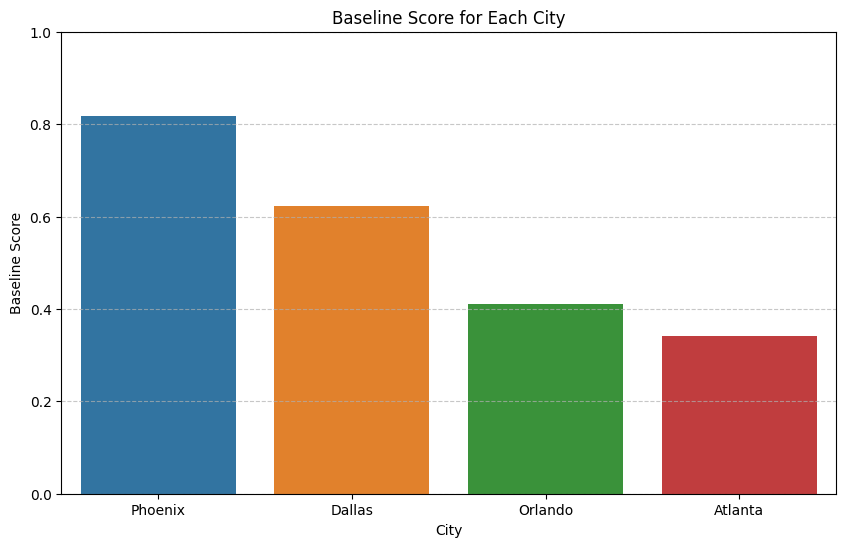

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by baseline_score for better visualization
plot_data = city_features.sort_values(by='baseline_score', ascending=False)

city_palette= {
    "Phoenix": "#1f77b4",
    "Dallas": "#ff7f0e",
    "Orlando": "#2ca02c",
    "Atlanta":"#d62728",
}

plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='baseline_score', data=plot_data, palette=city_palette)
plt.title('Baseline Score for Each City')
plt.xlabel('City')
plt.ylabel('Baseline Score')
plt.ylim(0, 1) # Scores are normalized between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-154920741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='median_household_income', data=plot_data, palette=city_palette)


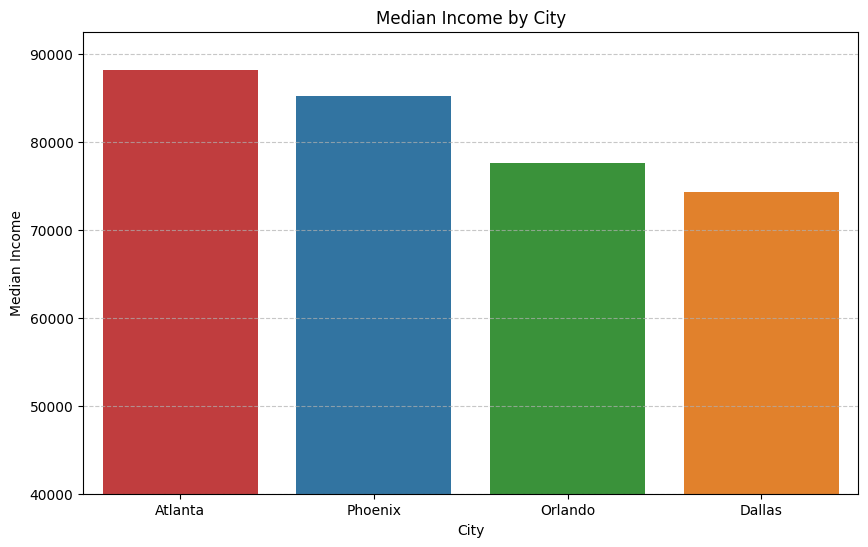

In [ ]:
# Sort the DataFrame by Median Income
plot_data = city_features.sort_values(by='median_household_income', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='median_household_income', data=plot_data, palette=city_palette)
plt.title('Median Income by City')
plt.xlabel('City')
plt.ylabel('Median Income')
plt.ylim(40000,None) #Raising the lower limit to $40k
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-4025565144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='total_population', data=plot_data, palette=city_palette)


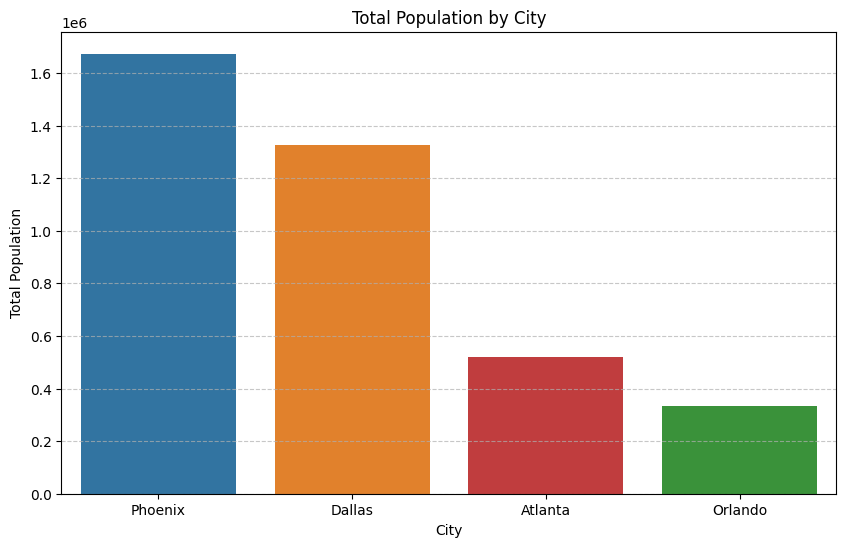

In [ ]:
# Sort the DataFrame by Total pop
plot_data = city_features.sort_values(by='total_population', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='total_population', data=plot_data, palette=city_palette)
plt.title('Total Population by City')
plt.xlabel('City')
plt.ylabel('Total Population')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Paragraphs about cities

Phoenix:
---
Phoenix is the city with the highest baseline score, indicating that when compared to the other cities it has a higher "attractiveness" for retail site selection when compared to the other options. While Phoenix is in third place for traffic index, it leads in population, and comes second in median income. Currently, Phoenix is in the lead of the retail site selection.

Dallas:
---
Dallas is the second highest city in terms of baseline scoring, should Phoenix not be a reasonable city for retail site selection then Dallas will be the fall-back option. With our current baseline scoring model, Dallas ranks the highest in traffic index, second in population and last in median income. When considering the factors listed, Dallas is not a strong contender when compared to Phoenix due to being the lowest in median income. Phoenix should still be considered over this option.

Atlanta and Orlando:
---
Both of these options should not be considered for retail site selection. When considering both cities their populations are both significantly lower than Dallas or Phoenix. Atlanta and Orlando have the highest and 3rd highest median income respectively with Orlando having the highest second highest traffic index score, but these factors are unable to bring their baseline scores close to Phoenix. AS a result of our current scoring scheme these two cities should be avoided for selection in favor of Phoenix.

# Submarkets

## Avondale (Phoenix AZ)



In [ ]:
# population: 90,600
# median income: $81,620
# retail density manual count: 125

pop_avondale = 90600
inc_avondale = 81620
retail_avondale = 125

score_avondale = 0.3 * pop_avondale + 0.3 * inc_avondale + 0.4 * retail_avondale

print(score_avondale)

52350.2


## Lake Mary (Orlando FL)

In [ ]:
# population: 16,700
# median income: $116,944
# retail density manual count: 200

pop_lake_mary = 16700
inc_lake_mary = 116944
retail_lake_mary = 200

score_lake_mary = 0.3 * pop_lake_mary + 0.3 * inc_lake_mary + 0.4 * retail_lake_mary

print(score_lake_mary)

80419.4


## Lake Nona (Orlando FL)

In [ ]:
# population: 22,533
# median income: $113,712
# retail density manual count: 30

pop_lake_nona = 22533
inc_lake_nona = 113712
retail_lake_nona = 30

score_lake_nona = 0.3 * pop_lake_nona + 0.3 * inc_lake_nona + 0.4 * retail_lake_nona

print(score_lake_nona)

40885.5


# Sandy Springs (Atlanta GA)

In [ ]:
# population: 38,821
# median income: $101,593
# retail density manual count: 100

pop_sandy_springs = 38821
inc_sandy_springs = 101593
retail_sandy_springs = 100

score_sandy_springs = 0.3 * pop_sandy_springs + 0.3 * inc_sandy_springs + 0.4 * retail_sandy_springs

print(score_sandy_springs)

42164.2


## Princeton (Dallas TX)

In [ ]:
# population: 28,027
# median income: $90,809
# retail density manual count: 50

pop_princeton = 28027
inc_princeton = 90809
retail_princeton = 50

score_princeton = 0.3 * pop_princeton + 0.3 * inc_princeton + 0.4 * retail_princeton

print(score_princeton)

33928.1


## Submarkets ranked by baseline score

In [ ]:
scores = [score_avondale, score_lake_mary, score_lake_nona, score_sandy_springs, score_princeton]

submarket_result = pd.DataFrame({"submarket": ["Avondale", "Lake Mary", "Lake Nona", "Sandy Springs", "Princeton"], "score": scores})

# sort
submarket_result_2 = submarket_result.sort_values(by="score", ascending=False)

submarket_result_2

,submarket,score
1,Lake Mary,80419.4
3,Sandy Springs,65464.0
0,Avondale,52350.2
2,Lake Nona,49812.0
4,Princeton,33928.1


## Submarket Selection

The Lake Mary submarket had the highest score, followed by Sandy Springs, despite Orlando and Atlanta having lower baseline scores. Next was Avondale, a submarket of Phoenix, which had the highest baseline score. This suggests that submarkets can behave differently than the overall city, so they want to be considered for more granular analysis.

Here are potential retail shopping centers in the top three submarkets to select as the retail address for the site:

4300 W Lake Mary Blvd, Lake Mary, FL 32746

200 Hammond Dr NE, Sandy Springs, GA 30328

W McDowell Rd, Avondale, AZ 85392
